<a href="https://colab.research.google.com/github/anuppathak274-lab/Customer-Churn-Prediction/blob/main/ecommerce_customer_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Dependencies

In [2]:
!pip install -q imbalanced-learn lifetimes mlxtend
print("Dependencies ready.")

Dependencies ready.


Generate Synthetic e-commerce Data

In [3]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

N_CUSTOMERS = 3000
N_PRODUCTS = 200
START_DATE = datetime(2023, 1, 1)
END_DATE = datetime(2024, 12, 31)
CATEGORIES = ["Electronics", "Fashion", "Home & Kitchen", "Beauty",
              "Sports", "Books", "Toys", "Grocery"]

def generate_customers(n=N_CUSTOMERS):
    personas = np.random.choice(
        ["loyal_high_value", "loyal_low_value", "occasional", "one_time", "churn_risk"],
        size=n, p=[0.12, 0.18, 0.35, 0.20, 0.15]
    )
    signup_days_ago = np.random.randint(30, 730, size=n)
    signup_dates = [END_DATE - timedelta(days=int(d)) for d in signup_days_ago]
    return pd.DataFrame({
        "CustomerID": np.arange(10000, 10000 + n),
        "Persona": personas,
        "SignupDate": signup_dates,
        "Country": np.random.choice(["India", "USA", "UK", "Germany", "UAE", "Australia"],
                                     size=n, p=[0.4, 0.2, 0.15, 0.1, 0.1, 0.05])
    })

def generate_products(n=N_PRODUCTS):
    products = pd.DataFrame({
        "StockCode": [f"P{str(i).zfill(4)}" for i in range(n)],
        "Category": np.random.choice(CATEGORIES, size=n),
    })
    products["UnitPrice"] = np.round(np.random.gamma(shape=2.0, scale=15.0, size=n) + 5, 2)
    return products

PERSONA_PARAMS = {
    "loyal_high_value":  dict(rate=3.5, active_prob=0.95, qty=(2, 6), price_mult=1.6),
    "loyal_low_value":   dict(rate=2.0, active_prob=0.85, qty=(1, 3), price_mult=0.9),
    "occasional":        dict(rate=0.8, active_prob=0.55, qty=(1, 3), price_mult=1.0),
    "one_time":          dict(rate=0.15, active_prob=0.05, qty=(1, 2), price_mult=0.8),
    "churn_risk":        dict(rate=1.2, active_prob=0.15, qty=(1, 2), price_mult=0.7),
}

# Category affinity pairs: baskets deliberately co-purchase these together some of
# the time, so the market-basket analysis later has genuine "frequently bought
# together" signal to discover (real e-commerce baskets aren't purely random either).
CATEGORY_AFFINITY = {
    "Electronics": "Books", "Books": "Electronics",
    "Fashion": "Beauty", "Beauty": "Fashion",
    "Sports": "Beauty",
    "Toys": "Books",
    "Grocery": "Home & Kitchen", "Home & Kitchen": "Grocery",
}
AFFINITY_STRENGTH = 0.55  # probability a 2nd+ item follows the affinity pattern

def pick_basket(products, n_items):
    # Pick n_items products for one order, with some probability of following
    # a category-affinity pattern instead of pure random selection.
    first = products.sample(1)
    picked = [first]
    first_category = first["Category"].iloc[0]
    companion_category = CATEGORY_AFFINITY.get(first_category)
    for _ in range(n_items - 1):
        if companion_category is not None and np.random.rand() < AFFINITY_STRENGTH:
            pool = products[products["Category"] == companion_category]
        else:
            pool = products
        picked.append(pool.sample(1))
    return pd.concat(picked, ignore_index=True)

def generate_transactions(customers, products):
    rows = []
    invoice_counter = 500000
    for _, cust in customers.iterrows():
        params = PERSONA_PARAMS[cust["Persona"]]
        signup = cust["SignupDate"]
        active_span_days = (END_DATE - signup).days
        if active_span_days <= 0:
            continue
        if np.random.rand() > params["active_prob"]:
            last_active_day = np.random.randint(0, max(active_span_days - 30, 1))
            effective_end = signup + timedelta(days=last_active_day)
        else:
            effective_end = END_DATE
        n_months = max((effective_end - signup).days / 30.0, 0.5)
        n_orders = min(np.random.poisson(lam=params["rate"] * n_months), 80)
        if n_orders == 0:
            continue
        order_days = np.sort(np.random.randint(0, max((effective_end - signup).days, 1), size=n_orders))
        for day_offset in order_days:
            invoice_counter += 1
            order_date = signup + timedelta(days=int(day_offset))
            n_items = np.random.randint(1, 5)
            chosen_products = pick_basket(products, n_items)
            for _, prod in chosen_products.iterrows():
                qty = np.random.randint(params["qty"][0], params["qty"][1] + 1)
                price = round(prod["UnitPrice"] * params["price_mult"] * np.random.uniform(0.9, 1.1), 2)
                rows.append({
                    "InvoiceNo": invoice_counter, "CustomerID": cust["CustomerID"],
                    "StockCode": prod["StockCode"], "Category": prod["Category"],
                    "Quantity": qty, "UnitPrice": price, "InvoiceDate": order_date,
                    "Country": cust["Country"],
                })
    df = pd.DataFrame(rows)
    df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
    return df

print("Generating customers, products, transactions...")
customers = generate_customers()
products = generate_products()
transactions = generate_transactions(customers, products)
print(f"Done: {len(transactions):,} transactions across {transactions['CustomerID'].nunique():,} customers")
transactions.head()

Generating customers, products, transactions...
Done: 101,659 transactions across 2,545 customers


,InvoiceNo,CustomerID,StockCode,Category,Quantity,UnitPrice,InvoiceDate,Country,TotalAmount
0,500001,10000,P0133,Electronics,3,15.10,2024-01-28,India,45.30
1,500001,10000,P0117,Sports,3,21.45,2024-01-28,India,64.35
2,500002,10000,P0021,Grocery,2,21.87,2024-02-01,India,43.74
3,500002,10000,P0122,Home & Kitchen,2,35.16,2024-02-01,India,70.32
4,500002,10000,P0071,Home & Kitchen,2,34.66,2024-02-01,India,69.32


Exploratory Data Analysis

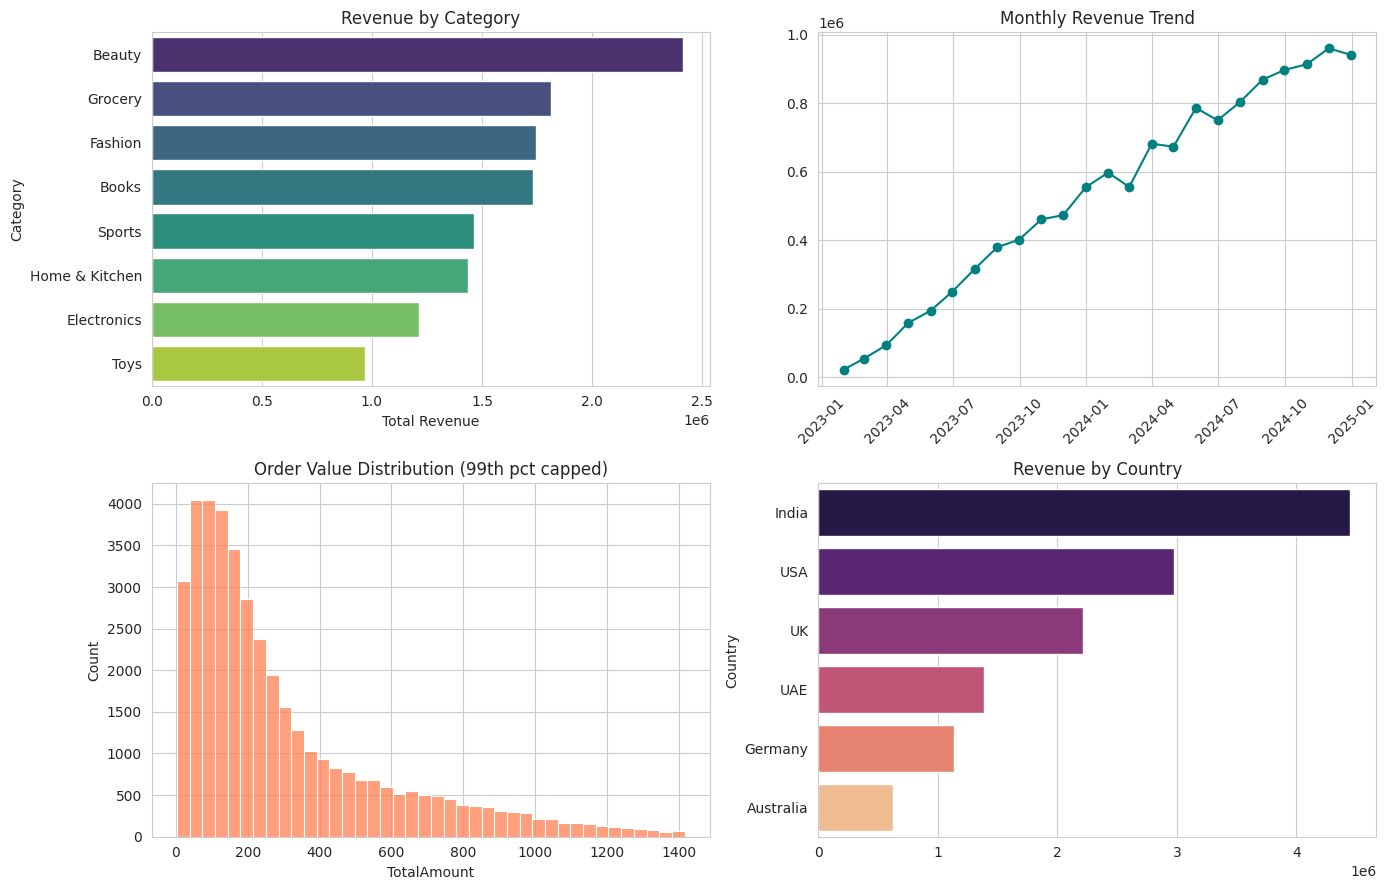

Total revenue: $12,792,693
Total orders: 40,527
Avg order value: $315.66


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Revenue by category
cat_rev = transactions.groupby("Category")["TotalAmount"].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, hue=cat_rev.index, ax=axes[0,0], palette="viridis", legend=False)
axes[0,0].set_title("Revenue by Category")
axes[0,0].set_xlabel("Total Revenue")

# Monthly revenue trend
monthly = transactions.set_index("InvoiceDate").resample("ME")["TotalAmount"].sum()
axes[0,1].plot(monthly.index, monthly.values, marker="o", color="teal")
axes[0,1].set_title("Monthly Revenue Trend")
axes[0,1].tick_params(axis="x", rotation=45)

# Order value distribution
order_totals = transactions.groupby("InvoiceNo")["TotalAmount"].sum()
sns.histplot(order_totals[order_totals < order_totals.quantile(0.99)], bins=40, ax=axes[1,0], color="coral")
axes[1,0].set_title("Order Value Distribution (99th pct capped)")

# Revenue by country
country_rev = transactions.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False)
sns.barplot(x=country_rev.values, y=country_rev.index, hue=country_rev.index, ax=axes[1,1], palette="magma", legend=False)
axes[1,1].set_title("Revenue by Country")

plt.tight_layout()
plt.show()

print(f"Total revenue: ${transactions['TotalAmount'].sum():,.0f}")
print(f"Total orders: {transactions['InvoiceNo'].nunique():,}")
print(f"Avg order value: ${order_totals.mean():.2f}")

RFM Feature Engineering

In [5]:
def build_rfm_features(df, snapshot_date=None):
    if snapshot_date is None:
        snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
    grp = df.groupby("CustomerID")
    rfm = grp.agg(
        Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalAmount", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        CategoryDiversity=("Category", "nunique"),
    ).reset_index()
    rfm["Tenure"] = (snapshot_date - rfm["FirstPurchase"]).dt.days
    rfm["AvgOrderValue"] = (rfm["Monetary"] / rfm["Frequency"]).round(2)
    order_dates = df.groupby("CustomerID")["InvoiceDate"].apply(
        lambda x: x.sort_values().diff().dt.days.mean())
    rfm["AvgDaysBetween"] = rfm["CustomerID"].map(order_dates).fillna(rfm["Tenure"])
    return rfm.drop(columns=["FirstPurchase", "LastPurchase"])

def add_rfm_scores(rfm, bins=5):
    rfm = rfm.copy()
    rfm["R_score"] = pd.qcut(rfm["Recency"].rank(method="first"), bins, labels=list(range(bins,0,-1))).astype(int)
    rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), bins, labels=list(range(1,bins+1))).astype(int)
    rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), bins, labels=list(range(1,bins+1))).astype(int)
    rfm["RFM_Score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
    def label(row):
        if row["RFM_Score"] >= 13: return "Champions"
        elif row["RFM_Score"] >= 10: return "Loyal Customers"
        elif row["RFM_Score"] >= 7: return "Potential Loyalists"
        elif row["RFM_Score"] >= 5: return "At Risk"
        else: return "Lost / Hibernating"
    rfm["RFM_Segment"] = rfm.apply(label, axis=1)
    return rfm

rfm = build_rfm_features(transactions)
rfm = add_rfm_scores(rfm)
print(rfm["RFM_Segment"].value_counts())
rfm.head()

RFM_Segment
Champions              633
Potential Loyalists    591
Loyal Customers        523
At Risk                410
Lost / Hibernating     388
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,CategoryDiversity,Tenure,AvgOrderValue,AvgDaysBetween,R_score,F_score,M_score,RFM_Score,RFM_Segment
0,10000,317,3,602.11,6,338,200.70,2.625000,1,2,2,5,At Risk
1,10001,88,19,1961.29,8,531,103.23,7.910714,3,4,3,10,Loyal Customers
2,10002,140,1,181.45,4,140,181.45,0.000000,2,1,1,4,Lost / Hibernating
3,10004,24,30,4876.07,8,464,162.54,5.714286,4,5,4,13,Champions
4,10005,459,12,1849.47,7,638,154.12,6.392857,1,3,3,7,Potential Loyalists


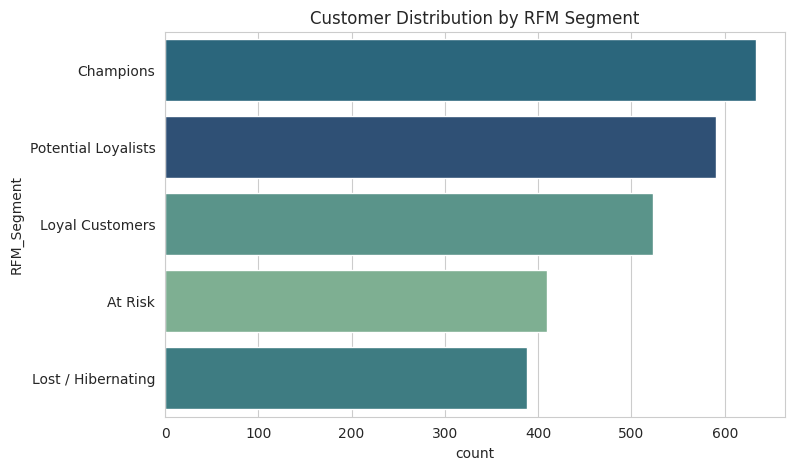

In [6]:
plt.figure(figsize=(8,5))
seg_order = rfm["RFM_Segment"].value_counts().index
sns.countplot(data=rfm, y="RFM_Segment", hue="RFM_Segment", order=seg_order, palette="crest", legend=False)
plt.title("Customer Distribution by RFM Segment")
plt.show()

K-Means Customer Segmentation

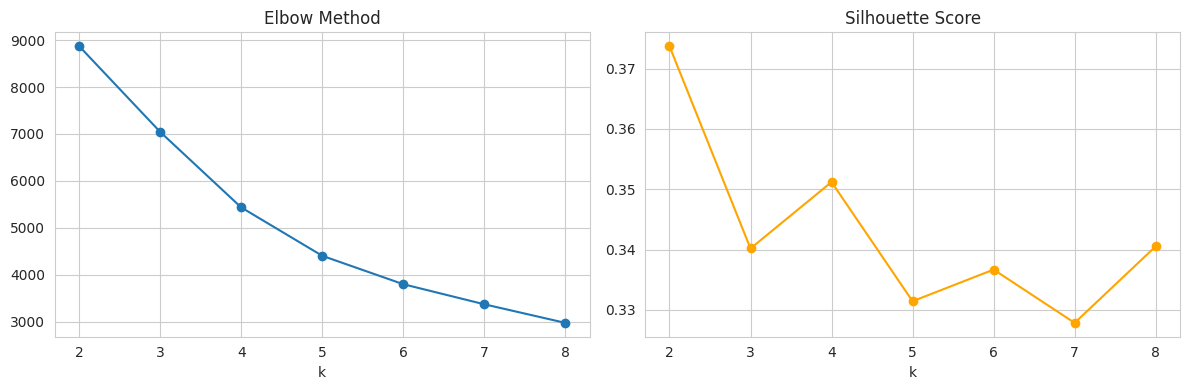

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

FEATURES = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "Tenure", "CategoryDiversity"]

X = rfm[FEATURES].copy()
for col in ["Monetary", "Frequency", "AvgOrderValue"]:
    X[col] = np.log1p(X[col])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow + silhouette to pick k
inertias, sils = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(list(k_range), inertias, marker="o"); ax[0].set_title("Elbow Method"); ax[0].set_xlabel("k")
ax[1].plot(list(k_range), sils, marker="o", color="orange"); ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()

            Recency  Frequency      Monetary  value_rank  recency_rank  \
Cluster                                                                  
0         13.614943  46.462644  25882.817328         1.0           1.0   
1         58.000000   8.213740   1414.532198         3.0           2.0   
2        425.332454   3.968338    496.959736         4.0           5.0   
3         76.190476  22.749660   3514.626626         2.0           3.0   
4        138.616822   1.759346    204.102126         5.0           4.0   

                  ClusterName  
Cluster                        
0            High-Value Loyal  
1        Regular / Occasional  
2           Churned / Dormant  
3                  High-Value  
4                     At Risk  


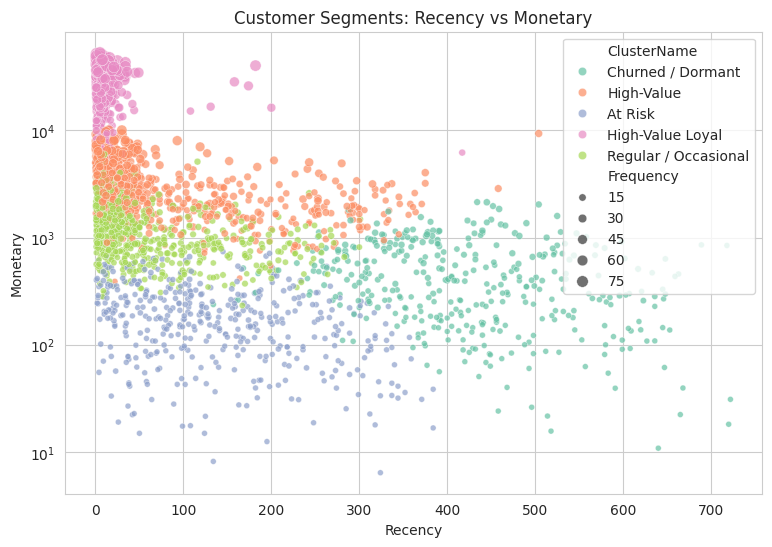

In [8]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
cluster_summary["value_rank"] = cluster_summary["Monetary"].rank(ascending=False)
cluster_summary["recency_rank"] = cluster_summary["Recency"].rank(ascending=True)

def name_cluster(row):
    if row["value_rank"] <= 1 and row["recency_rank"] <= 2: return "High-Value Loyal"
    elif row["recency_rank"] >= K: return "Churned / Dormant"
    elif row["recency_rank"] >= K - 1: return "At Risk"
    elif row["value_rank"] <= 2: return "High-Value"
    else: return "Regular / Occasional"

cluster_summary["ClusterName"] = cluster_summary.apply(name_cluster, axis=1)
rfm["ClusterName"] = rfm["Cluster"].map(cluster_summary["ClusterName"])
print(cluster_summary)

plt.figure(figsize=(9,6))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="ClusterName", size="Frequency",
                 palette="Set2", alpha=0.7)
plt.title("Customer Segments: Recency vs Monetary")
plt.yscale("log")
plt.show()

Churn Prediction

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

CHURN_THRESHOLD_DAYS = 90

CHURN_FEATURES = ["Frequency","Monetary","AvgOrderValue","Tenure","CategoryDiversity","AvgDaysBetween"]

rfm["Churned"] = (rfm["Recency"] > CHURN_THRESHOLD_DAYS).astype(int)
print("Churn rate:", rfm["Churned"].mean().round(3))

X = rfm[CHURN_FEATURES]
y = rfm["Churned"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

churn_scaler = StandardScaler()
X_train_s = churn_scaler.fit_transform(X_train)
X_test_s = churn_scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_s, y_train)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, eval_metric="logloss", random_state=42),
}

results = {}
fitted = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    preds = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:,1]
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average="binary")
    auc = roc_auc_score(y_test, proba)
    results[name] = {"precision": round(precision,3), "recall": round(recall,3),
                      "f1": round(f1,3), "roc_auc": round(auc,3)}
    fitted[name] = model

results_df = pd.DataFrame(results).T
print(results_df)

best_name = results_df["f1"].idxmax()
best_churn_model = fitted[best_name]
print(f"\nBest model: {best_name}")

Churn rate: 0.401
                    precision  recall     f1  roc_auc
LogisticRegression      0.776   0.868  0.819    0.930
RandomForest            0.879   0.892  0.886    0.966
XGBoost                 0.935   0.917  0.926    0.987

Best model: XGBoost


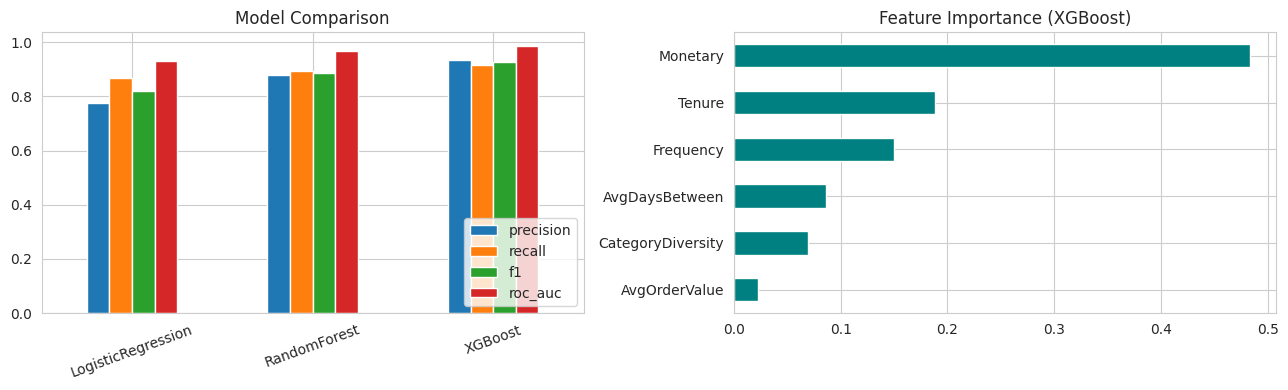

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
results_df[["precision","recall","f1","roc_auc"]].plot(kind="bar", ax=ax[0])
ax[0].set_title("Model Comparison"); ax[0].legend(loc="lower right"); ax[0].set_xticklabels(results_df.index, rotation=20)

if hasattr(best_churn_model, "feature_importances_"):
    importances = pd.Series(best_churn_model.feature_importances_, index=CHURN_FEATURES).sort_values()
    importances.plot(kind="barh", ax=ax[1], color="teal")
    ax[1].set_title(f"Feature Importance ({best_name})")
plt.tight_layout(); plt.show()

Customer Lifetime Value (CLV)

MAE: 873.63
R2: 0.959


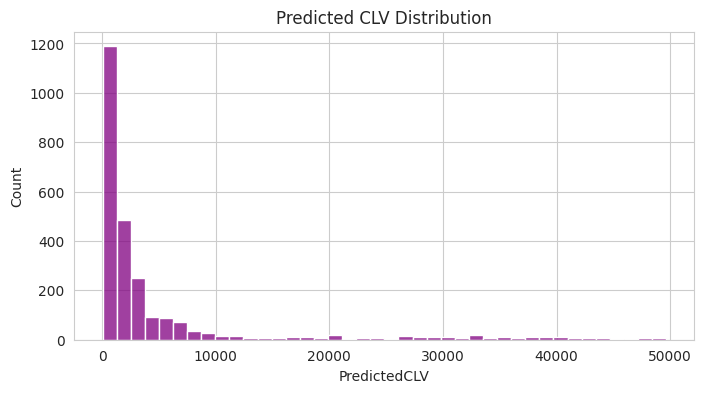

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

CLV_FEATURES = ["Recency","Frequency","Tenure","CategoryDiversity","AvgDaysBetween"]
X = rfm[CLV_FEATURES]
y = rfm["Monetary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clv_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
clv_model.fit(X_train, y_train)
preds = clv_model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"R2: {r2_score(y_test, preds):.3f}")

rfm["PredictedCLV"] = clv_model.predict(rfm[CLV_FEATURES])
plt.figure(figsize=(8,4))
sns.histplot(rfm["PredictedCLV"], bins=40, color="purple")
plt.title("Predicted CLV Distribution")
plt.show()

BG/NBD + Gamma-Gamma (probabilistic CLV)

In [12]:
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

snapshot_date = transactions["InvoiceDate"].max()
summary = summary_data_from_transaction_data(
    transactions, customer_id_col="CustomerID", datetime_col="InvoiceDate",
    monetary_value_col="TotalAmount", observation_period_end=snapshot_date,
)

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary["frequency"], summary["recency"], summary["T"])

repeat_customers = summary[summary["frequency"] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(repeat_customers["frequency"], repeat_customers["monetary_value"])

summary["predicted_purchases_12m"] = bgf.predict(360, summary["frequency"], summary["recency"], summary["T"])
summary["predicted_clv_12m"] = 0.0
summary.loc[repeat_customers.index, "predicted_clv_12m"] = ggf.customer_lifetime_value(
    bgf, repeat_customers["frequency"], repeat_customers["recency"], repeat_customers["T"],
    repeat_customers["monetary_value"], time=12, freq="D", discount_rate=0.01,
)

summary.sort_values("predicted_clv_12m", ascending=False).head(10)[
    ["frequency","recency","predicted_purchases_12m","predicted_clv_12m"]]

,frequency,recency,predicted_purchases_12m,predicted_clv_12m
CustomerID,,,,
10764,21.0,153.0,39.996274,31981.186169
10171,14.0,68.0,45.884707,31387.602825
11426,28.0,195.0,42.399639,30550.451929
12294,41.0,240.0,50.697696,30171.307597
10100,39.0,297.0,41.441033,28612.855060
10132,15.0,108.0,38.061934,28465.696962
11644,60.0,368.0,50.916665,28245.110473
11116,35.0,223.0,46.170968,28164.528717
10957,72.0,574.0,42.078166,27979.666131


Recommendation Engine

In [13]:
from sklearn.decomposition import TruncatedSVD

interaction_matrix = transactions.pivot_table(
    index="CustomerID", columns="Category", values="Quantity", aggfunc="sum", fill_value=0)

svd = TruncatedSVD(n_components=5, random_state=42)
latent = svd.fit_transform(interaction_matrix)
reconstructed = np.dot(latent, svd.components_)

def recommend_categories(customer_id, top_n=3):
    idx = interaction_matrix.index.get_loc(customer_id)
    scores = pd.Series(reconstructed[idx], index=interaction_matrix.columns)
    already_bought = interaction_matrix.loc[customer_id]
    scores = scores[already_bought == 0]
    return scores.sort_values(ascending=False).head(top_n).index.tolist()

sample_customer = interaction_matrix.index[0]
print(f"Recommended categories for customer {sample_customer}: {recommend_categories(sample_customer)}")

Recommended categories for customer 10000: ['Books', 'Toys']


In [14]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

baskets = transactions.groupby("InvoiceNo")["Category"].apply(lambda x: list(set(x))).tolist()
te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_items = apriori(basket_df, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.15)
rules = rules.sort_values("lift", ascending=False)
rules[["antecedents","consequents","support","confidence","lift"]].head(10)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
8,(Electronics),(Books),0.123671,0.592085,2.222211
9,(Books),(Electronics),0.123671,0.464160,2.222211
22,(Grocery),(Home & Kitchen),0.163076,0.541411,2.152418
21,(Home & Kitchen),(Grocery),0.163076,0.648323,2.152418
27,"(Sports, Fashion)",(Beauty),0.027241,0.614699,1.818256
1,(Fashion),(Beauty),0.174452,0.581510,1.720083
2,(Beauty),(Fashion),0.174452,0.516021,1.720083
13,(Books),(Toys),0.082167,0.308390,1.705998
12,(Toys),(Books),0.082167,0.454545,1.705998
6,(Beauty),(Sports),0.119229,0.352675,1.454448


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Summary Dashboard

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

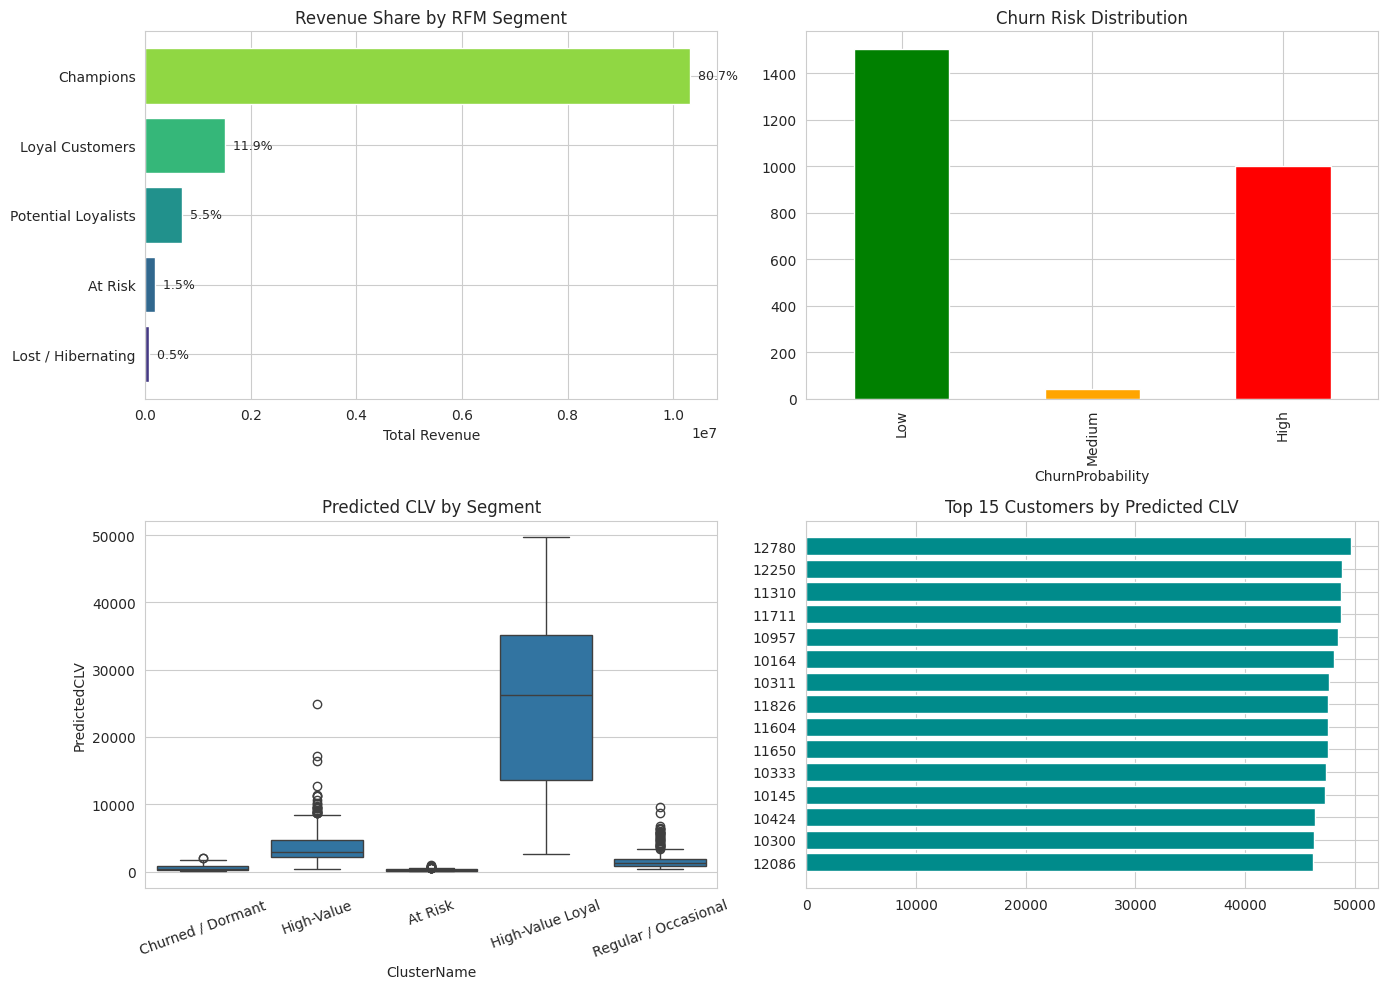

=== KEY METRICS ===
Total customers: 2,545
Churn rate: 40.1%
Avg predicted CLV: $4,984.82
High-risk customers: 1,002


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Segment revenue contribution
seg_rev = rfm.groupby("RFM_Segment")["Monetary"].sum().sort_values(ascending=True)
seg_rev_pct = (seg_rev / seg_rev.sum() * 100).round(1)
bars = axes[0,0].barh(seg_rev.index, seg_rev.values, color=sns.color_palette("viridis", len(seg_rev)))
for bar, pct in zip(bars, seg_rev_pct.values):
    axes[0,0].text(bar.get_width(), bar.get_y() + bar.get_height()/2, f"  {pct}%",
                   va="center", fontsize=9)
axes[0,0].set_title("Revenue Share by RFM Segment")
axes[0,0].set_xlabel("Total Revenue")

# Churn risk breakdown
churn_proba_all = best_churn_model.predict_proba(churn_scaler.transform(rfm[CHURN_FEATURES]))[:,1]
rfm["ChurnProbability"] = churn_proba_all
risk_bins = pd.cut(rfm["ChurnProbability"], bins=[0,0.3,0.6,1.0], labels=["Low","Medium","High"])
risk_bins.value_counts().reindex(["Low","Medium","High"]).plot(
    kind="bar", ax=axes[0,1], color=["green","orange","red"])
axes[0,1].set_title("Churn Risk Distribution")

# CLV vs Cluster
sns.boxplot(data=rfm, x="ClusterName", y="PredictedCLV", ax=axes[1,0])
axes[1,0].set_title("Predicted CLV by Segment")
axes[1,0].tick_params(axis="x", rotation=20)

# Top 15 highest CLV customers
top_clv = rfm.nlargest(15, "PredictedCLV")[["CustomerID","PredictedCLV"]]
axes[1,1].barh(top_clv["CustomerID"].astype(str), top_clv["PredictedCLV"], color="darkcyan")
axes[1,1].set_title("Top 15 Customers by Predicted CLV")
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

print("=== KEY METRICS ===")
print(f"Total customers: {len(rfm):,}")
print(f"Churn rate: {rfm['Churned'].mean():.1%}")
print(f"Avg predicted CLV: ${rfm['PredictedCLV'].mean():,.2f}")
print(f"High-risk customers: {(rfm['ChurnProbability'] > 0.6).sum():,}")